In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:

PRICES_1 = "prices_round_1_day_-2.csv"
PRICES_2 = "prices_round_1_day_-1.csv"
PRICES_3 = "prices_round_1_day_0.csv"

TRADES_1 = "trades_round_1_day_-2.csv"
TRADES_2 = "trades_round_1_day_-1.csv"
TRADES_3 = "trades_round_1_day_0.csv"

products = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]

In [25]:

prices = [pd.read_csv(PRICES_1, sep=";"), pd.read_csv(PRICES_2, sep=";"), pd.read_csv(PRICES_3, sep=";")]
trades = [pd.read_csv(TRADES_1, sep=";"), pd.read_csv(TRADES_2, sep=";"), pd.read_csv(TRADES_3, sep=";")]

In [26]:

prices[0].head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [ ]:

def process_prices(prices):
    for i in range(1, len(prices)):
        prices[i]["timestamp"] += prices[i - 1]["timestamp"].max() + 100
    
    prices = pd.concat(prices, axis=0)
    print(prices["timestamp"].min(), prices["timestamp"].max())
    
    # Group by product
    grouped = prices.groupby("product")
    
    product1 = grouped.get_group(products[0])
    product2 = grouped.get_group(products[1])
    
    product1 = product1.loc[(product1["mid_price"] > 0) & (product1["mid_price"].notna())]
    product2 = product2.loc[(product2["mid_price"] > 0) & (product2["mid_price"].notna())]
    return product1, product2

product1, product2 = process_prices(prices)


0 2999900


In [28]:
prices = pd.concat(prices, axis=0)

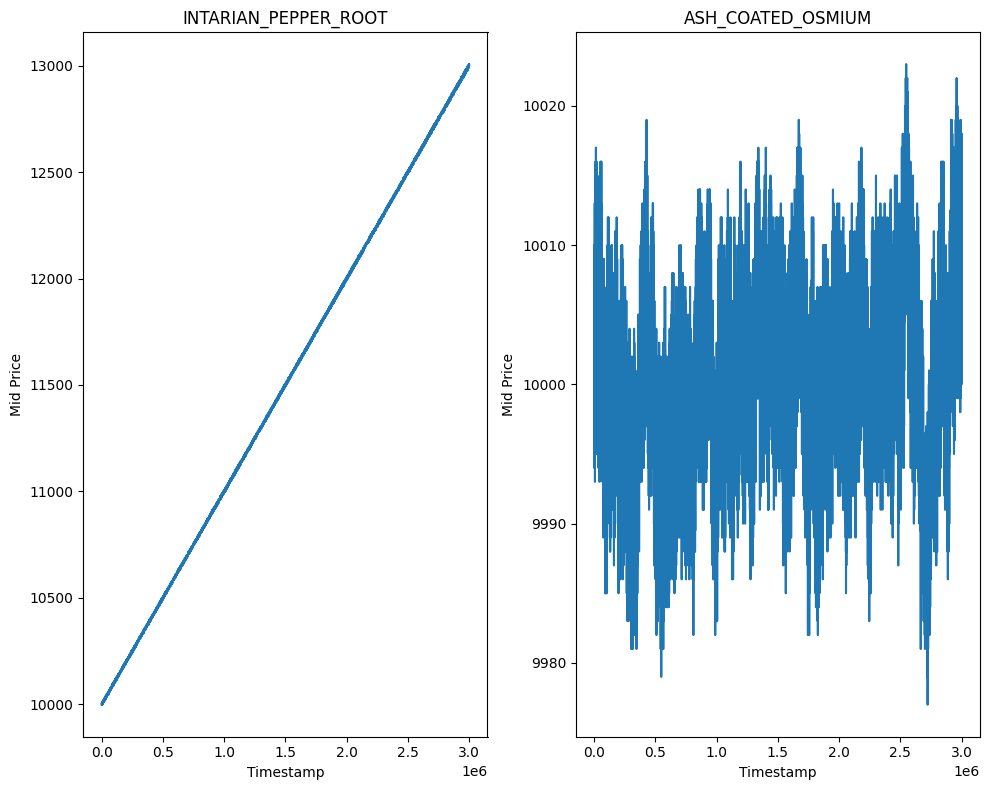

In [21]:
def visualize_prices(product1, product2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 8))
    
    axs[0].plot(product1["timestamp"], product1["mid_price"])
    axs[0].set_title(products[0])
    axs[0].set_xlabel("Timestamp")
    axs[0].set_ylabel("Mid Price")
    axs[1].plot(product2["timestamp"], product2["mid_price"])
    axs[1].set_title(products[1])
    axs[1].set_xlabel("Timestamp")
    axs[1].set_ylabel("Mid Price")
    plt.tight_layout()
    

visualize_prices(product1, product2)

Basic Statistics:
count    29951.000000
mean     10000.204234
std          5.349695
min       9977.000000
25%       9997.000000
50%      10000.500000
75%      10003.500000
max      10023.000000
Name: mid_price, dtype: float64


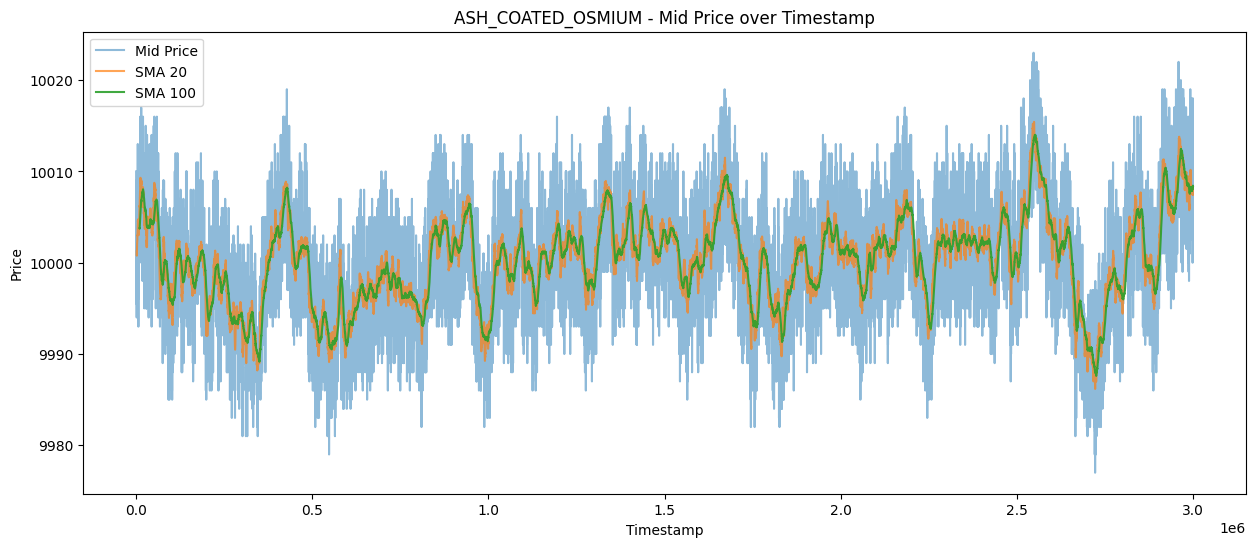

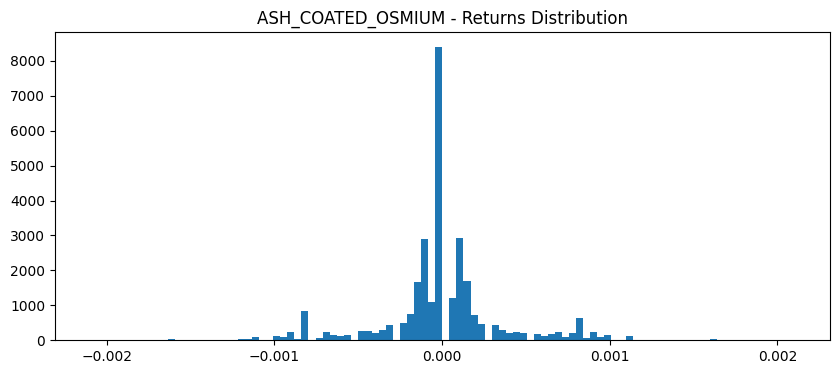

In [29]:
# Analyze ASH_COATED_OSMIUM (product2)
print("Basic Statistics:")
print(product2["mid_price"].describe())

# Check for moving averages / patterns
plt.figure(figsize=(15, 6))
plt.plot(product2["timestamp"], product2["mid_price"], label="Mid Price", alpha=0.5)

# Calculate some rolling statistics to find patterns
product2['SMA_20'] = product2['mid_price'].rolling(window=20).mean()
product2['SMA_100'] = product2['mid_price'].rolling(window=100).mean()

plt.plot(product2["timestamp"], product2['SMA_20'], label="SMA 20", alpha=0.7)
plt.plot(product2["timestamp"], product2['SMA_100'], label="SMA 100", alpha=0.9)

plt.title("ASH_COATED_OSMIUM - Mid Price over Timestamp")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.show()

# Check Returns Distribution
returns = product2["mid_price"].pct_change().dropna()
plt.figure(figsize=(10, 4))
plt.hist(returns, bins=100)
plt.title("ASH_COATED_OSMIUM - Returns Distribution")
plt.show()

Text(0.5, 1.0, 'Mid Price with Linear Fit')

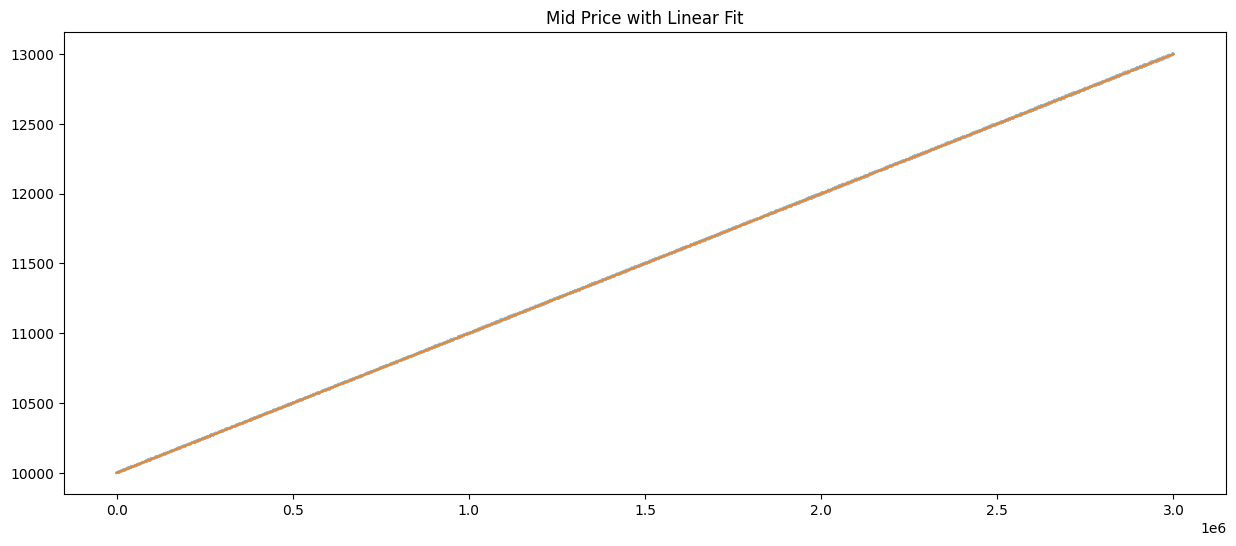

In [31]:

from sklearn.linear_model import LinearRegression

# drop 0s and NaNs
prices = prices.loc[(prices["mid_price"] > 0) & (prices["mid_price"].notna())]

# get intarian pepper root data
prices = prices.loc[prices["product"] == products[0]]

X, y = prices["timestamp"].values.reshape(-1, 1), prices["mid_price"].values
model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)

plt.figure(figsize=(15, 6))
plt.plot(prices["timestamp"], prices["mid_price"], label="Mid Price", alpha=0.5)
plt.plot(prices["timestamp"], predictions, label="Linear Fit", alpha=0.9)
plt.title("Mid Price with Linear Fit")


Text(0.5, 0, 'Timestamp')

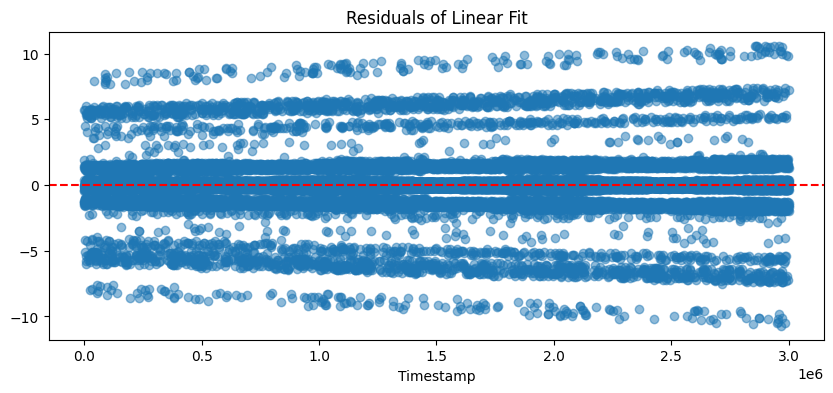

In [33]:
# residual plot
residuals = prices["mid_price"] - predictions
plt.figure(figsize=(10, 4))
plt.scatter(prices["timestamp"], residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals of Linear Fit")
plt.xlabel("Timestamp")

In [35]:

model.coef_, model.intercept_

(array([0.00100001]), np.float64(9999.987845643911))